In [5]:
# Add the Tesseract PPA (for Ubuntu 22.04 - Colab's current base)
!sudo add-apt-repository ppa:alex-p/tesseract-ocr-devel -y
!sudo apt-get update

# Install the latest Tesseract (5.x) with language packs
!sudo apt-get install tesseract-ocr -y  # Core engine
!sudo apt-get install libtesseract-dev -y  # Development files
!sudo apt-get install tesseract-ocr-eng -y  # English language data
!sudo apt-get install tesseract-ocr-osd -y  # Script and orientation detection
!sudo apt-get install tesseract-ocr-rus -y  # Script and orientation detection

!pip install opencv-python pytesseract numpy thefuzz easyocr

Repository: 'deb https://ppa.launchpadcontent.net/alex-p/tesseract-ocr-devel/ubuntu/ jammy main'
Description:
This PPA contains an OCR engine - libtesseract and a command line program - tesseract. The development version available here (currntly 5.0.0 ) is better in many aspects (functionality, speed, stability) but is not 100 % API compatible with version 4.0. Tesseract 4 added a new neural net (LSTM) based OCR engine which is focused on line recognition, but also still supports the legacy Tesseract OCR engine of Tesseract 3 which works by recognizing character patterns. Compatibility with Tesseract 3 is enabled by using the Legacy OCR Engine mode (--oem 0). It also needs traineddata files which support the legacy engine, for example those from the tessdata repository. Tesseract has unicode (UTF-8) support, and can recognize more than 100 languages "out of the box". Tesseract supports various output formats: plain text, hOCR (HTML), PDF, invisible-text-only PDF, TSV. The master branch

Python imports and some configurations

In [44]:
import pytesseract
import cv2
import numpy as np
import easyocr
from pathlib import Path
import thefuzz

from google.colab.patches import cv2_imshow

# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# configure tesseract
pytesseract.pytesseract.tesseract_cmd = "/usr/bin/tesseract"

!tesseract --version  # Check Tesseract version
print(pytesseract.get_tesseract_version())  # Verify pytesseract access

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
tesseract 5.5.0
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found OpenMP 201511
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8
 Found libcurl/7.81.0 OpenSSL/3.0.2 zlib/1.2.11 brotli/1.0.9 zstd/1.4.8 libidn2/2.3.2 libpsl/0.21.0 (+libidn2/2.3.2) libssh/0.9.6/openssl/zlib nghttp2/1.43.0 librtmp/2.3 OpenLDAP/2.5.17
5.5.0


Configure access to images

In [8]:
root = Path('/content/drive/MyDrive')
imgs_path = root / 'src_filtered_results'
img_path = imgs_path / '457242852.jpg'

Show the gray image

array([[150, 150, 151, ..., 174, 175, 175],
       [150, 150, 151, ..., 173, 173, 173],
       [149, 150, 151, ..., 174, 173, 172],
       ...,
       [109, 112, 112, ...,  95, 108, 106],
       [110, 114, 114, ..., 112, 105, 106],
       [107, 112, 113, ..., 104, 101, 106]], dtype=uint8)
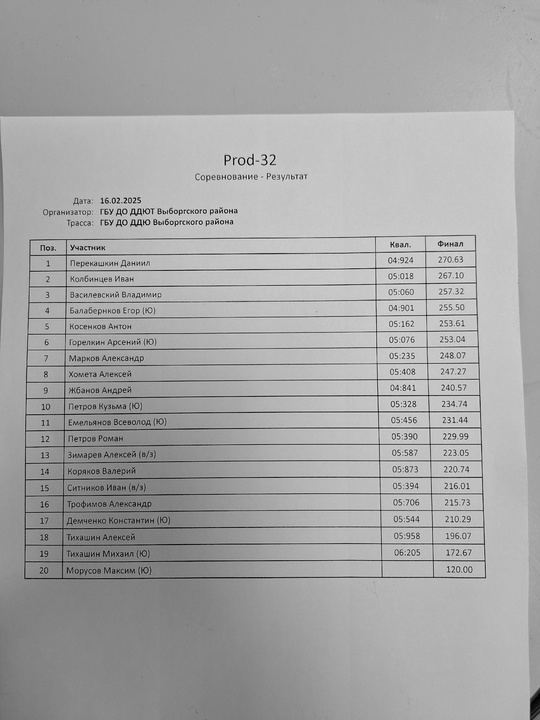

In [9]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray


Apply canny edge detection. Should "highlight" the edges for further use of Hough transform to dectect lines. If we have lines, we should be able to extract a table, at the very least, at most - each cell

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
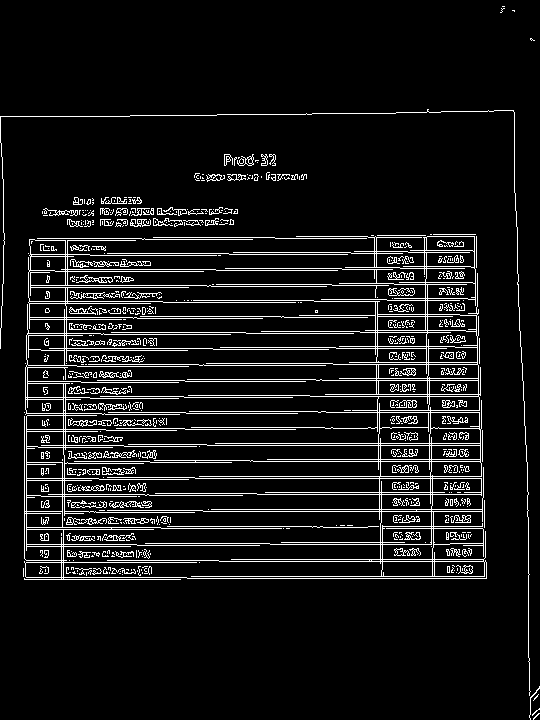

In [10]:
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
edges


Apply Hough transform to the canny-edged image. Plot the detected lines

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[102, 106, 117],
        [105, 109, 120],
        [107, 109, 120],
        ...,
        [ 47,  87, 129],
        [ 57, 100, 143],
        [ 53,  98, 142]],

       [[103, 107, 118],
        [107, 111, 122],
        [109, 111, 122],
        ...,
        [ 61, 103, 148],
        [ 48,  97, 143],
        [ 48,  98, 144]],

       [[100, 104, 115],
        [105, 109, 120],
        [108, 110, 121],
        ...,
        [ 51,  96, 140],
        [ 43,  92, 140],
        [ 46,  98, 145]]], dtype=uint8)
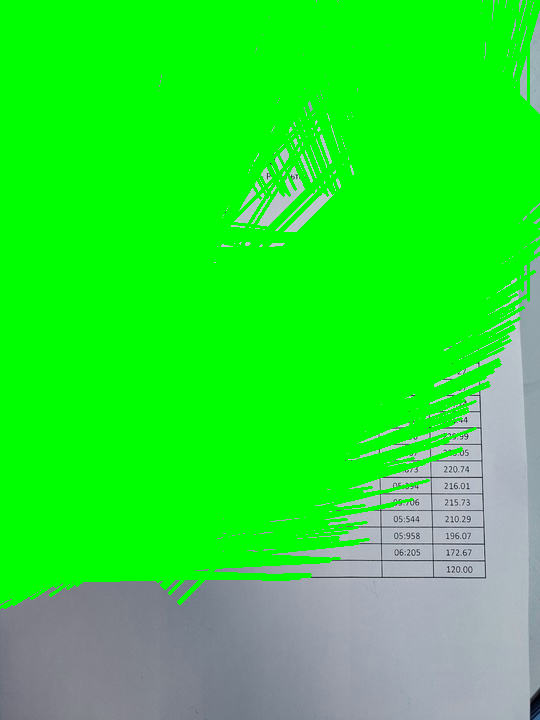

In [13]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=100)

plotted_lines = img.copy()
if lines is not None:
    llen =300
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + llen * (-b))
        y1 = int(y0 + llen * (a))
        x2 = int(x0 - llen * (-b))
        y2 = int(y0 - llen * (a))
        cv2.line(plotted_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plotted_lines

Oh, way to many lines. And it's clear, the lines are don't fully "highlight" the table

Let's try local merging with horizontal (1, 20) and vertical (20, 1) kernels. This should give us lines as well. Then we combine the 2 images to get a grid. After that, find and plot the contours

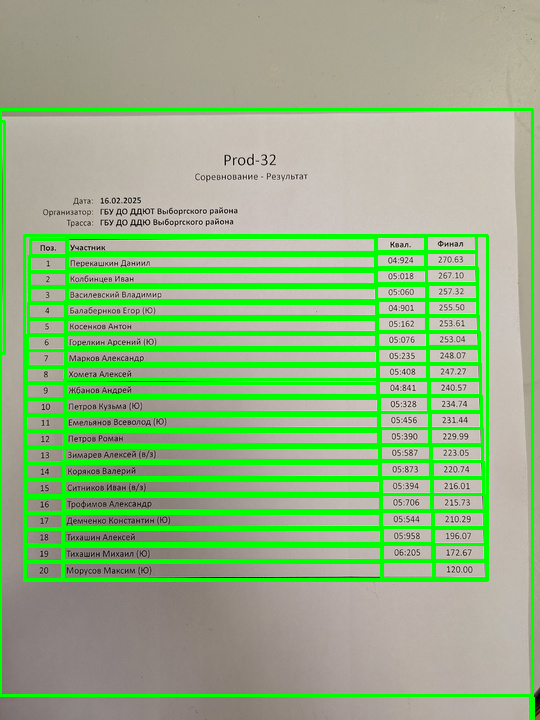

In [25]:
img = cv2.imread(img_path)
img_c = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Detect horizontal/vertical lines
kernel_h = np.ones((1, 20), np.uint8)
kernel_v = np.ones((20, 1), np.uint8)
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_h)
vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_v)

# Combine lines
grid = cv2.add(horizontal, vertical)

cells = []
# Find contours of cells
contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = cv2.contourArea(cnt)
    cells.append((x,y,w,h))
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Highlight cell

cv2_imshow(img)
img = img_c

That's nice! How we would filter the contours by different heuristics:

*   Width should be greater than height
*   Width to height ratio should be in (11, 20)
*   Median color of gray image should be in (130, 230)
*   Area of the contour should be in (0.9, 2.9)% of the image area



In [17]:
def filter_cnt(gray_img, cnt):
    x, y, w, h = cv2.boundingRect(cnt)
    iw, ih = gray_img.shape
    return (
        w > h
        and 11 < w / h < 20
        and 130 < np.median(gray_img[y : y + h, x : x + w]) < 230
        and 0.9 < w * h / (iw * ih) * 100 < 2.9
    )

Apply the filter to the contours to segment only "Participant" column

In [26]:
img = cv2.imread(img_path)
img_c = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Detect horizontal/vertical lines
kernel_h = np.ones((1, 20), np.uint8)
kernel_v = np.ones((20, 1), np.uint8)
horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_h)
vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_v)

# Combine lines
grid = cv2.add(horizontal, vertical)

cells = []
# Find contours of cells
contours, _ = cv2.findContours(grid, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = [cnt for cnt in contours if filter_cnt(gray, cnt)]
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cells.append((x,y,w,h))
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)  # Highlight cell

img
img = img_c

Let's try recognizing the text in the image

In [38]:
# sort the cells from high to low
cells = sorted(cells, key=lambda a: (a[1], a[0]))

reader = easyocr.Reader(["ru"])

def do_ocr(_img):
  cv2_imshow(_img)
  res = reader.readtext(_img)
  for r in res:
    _, text, confidence = r
    print(f"{text = !r}, {confidence = :.3f}")

for cell in cells[2:5]:
  x, y, w, h = cell
  full_img = img[y:y+h, x:x+w].copy()
  cropped_img = img[y:y+h, x:x+w//3].copy()
  for cell_img in (full_img, cropped_img):
    do_ocr(cell_img)

    gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
    do_ocr(gray)

    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    do_ocr(thresh)
    print()
  print()

text = 'БПГГЪННЕ', confidence = 0.033



text = 'ТПБниенИна', confidence = 0.037


text = 'ТПБниенИна', confidence = 0.037


text = 'БПГГЪНННННнЕ', confidence = 0.013




text = '=АЕЛЕЕ', confidence = 0.178



text = 'Часнл', confidence = 0.479
text = 'Ялаликтг', confidence = 0.167


text = 'Часнл', confidence = 0.479
text = 'Нладнм', confidence = 0.173


text = 'ВЗЕ#ЛеВский Впаднм#', confidence = 0.291




text = 'Етля Апанн', confidence = 0.129


text = 'Етля Апанн', confidence = 0.129


text = 'ЕНЛЕн Еп', confidence = 0.205



text = 'Бала 5грнкап Егор [=', confidence = 0.212


text = 'Бала 5грнкап Егор [=', confidence = 0.212


text = 'Ешлан ЕЕННЕП Егвв [ч]', confidence = 0.306




The results are not good at all. Let's try tesseract

In [41]:
# sort the cells from high to low
cells = sorted(cells, key=lambda a: (a[1], a[0]))


def do_ocr(_img, config):
  cv2_imshow(_img)
  res = pytesseract.image_to_string(cell_img, config=config, lang='rus').strip()
  print(f"{config}: {res = !r}")

def multi_config_ocr(_img):
  configs = [
      "",  # no config
      "--psm 6", # Assume a Single Uniform Block of Text
      "--psm 7", # Treat the Image as a Single Text Line
      ]
  for config in configs:
    do_ocr(_img, config)

for cell in cells[2:5]:
  x, y, w, h = cell
  full_img = img[y:y+h, x:x+w].copy()
  cropped_img = img[y:y+h, x:x+w//3].copy()
  for cell_img in (full_img, cropped_img):
    multi_config_ocr(cell_img)

    gray = cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY)
    multi_config_ocr(gray)

    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    multi_config_ocr(thresh)
    print()
  print()

: res = '[ Колбинцев Иван.'


--psm 6: res = ''


--psm 7: res = 'оон ООО ООС'


: res = '[ Колбинцев Иван.'


--psm 6: res = ''


--psm 7: res = 'оон ООО ООС'


: res = '[ Колбинцев Иван.'


--psm 6: res = ''


--psm 7: res = 'оон ООО ООС'



: res = ''


--psm 6: res = ''


--psm 7: res = ''


: res = ''


--psm 6: res = ''


--psm 7: res = ''


: res = ''


--psm 6: res = ''


--psm 7: res = ''




: res = '[ эсилевский Владимир'


--psm 6: res = ''


--psm 7: res = ''


: res = '[ эсилевский Владимир'


--psm 6: res = ''


--psm 7: res = ''


: res = '[ эсилевский Владимир'


--psm 6: res = ''


--psm 7: res = ''



: res = ''


--psm 6: res = ''


--psm 7: res = ''


: res = ''


--psm 6: res = ''


--psm 7: res = ''


: res = ''


--psm 6: res = ''


--psm 7: res = ''




: res = '[6злэберннов Егор (Ю).'


--psm 6: res = '[6злэберннов Егор (Ю).'


--psm 7: res = '[6злэберннов Егор (Ю).'


: res = '[6злэберннов Егор (Ю).'


--psm 6: res = '[6злэберннов Егор (Ю).'


--psm 7: res = '[6злэберннов Егор (Ю).'


: res = '[6злэберннов Егор (Ю).'


--psm 6: res = '[6злэберннов Егор (Ю).'


--psm 7: res = '[6злэберннов Егор (Ю).'



: res = '[6злэберннов Егор (Ю)'


--psm 6: res = ''


--psm 7: res = ''


: res = '[6злэберннов Егор (Ю)'


--psm 6: res = ''


--psm 7: res = ''


: res = '[6злэберннов Егор (Ю)'


--psm 6: res = ''


--psm 7: res = ''




Ok, so it turns out, that we should use tesseract and just a cropped image. Graying or thresholding it didn't help much. Same with cropping the image so that it mostly contains a text

Setting different `--psm` parameters didn't help at all

Let's try adding whitelist to remove non-alpha characters

In [42]:
# sort the cells from high to low
cells = sorted(cells, key=lambda a: (a[1], a[0]))

allowable_chars = "абвгдеёжзийклмнопрстуфхцчшщъыэюя"
allowable_chars += allowable_chars.upper()
allowable_chars += " "

for cell in cells[2:5]:
  x,y,w,h = cell
  cell_img = img[y:y+h, x:x+w].copy()
  cell_text = pytesseract.image_to_string(cell_img, config=f"-c tessedit_char_whitelist={allowable_chars} -c preserve_interword_spaces=1", lang='rus').strip()
  cv2_imshow(cell_img)
  print(f"{cell_text = !r}")
  print()

cell_text = 'КолбинцевИван'



cell_text = 'эсилевскийВладимир'



cell_text = 'злэбернновЕгорЮ'



Oh, nice. Let's add fuzzy matching to ease editing the names

In [46]:
from thefuzz import process

possible_fullnames = [
    "Перекашкин Даниил",
    "Колбинцев Иван",
    "Василевский Владимир",
    "Балабериков Егор",
    "Косенков Антон",
    "Горелкин Арсений",
    "Марков Александр",
    "Хомета Аленсей",
    "Жбанов Андрей",
    "Петров Кузыма",
    "Емельянов Всеволод",
    "Петров Роман",
    "Зимарев Алексей",
    "Коряков Валерий",
    "Ситников Иван",
    "Трофимов Александр",
    "Демченко Константин",
    "Тихашин Алексей",
    "Тихашин Михаил",
    "Морусов Максим",
]

# sort the cells from high to low
cells = sorted(cells, key=lambda a: (a[1], a[0]))

allowable_chars = "абвгдеёжзийклмнопрстуфхцчшщъыэюя"
allowable_chars += allowable_chars.upper()
allowable_chars += " "

for cell in cells[2:5]:
  x,y,w,h = cell
  cell_img = img[y:y+h, x:x+w].copy()
  cell_text = pytesseract.image_to_string(cell_img, config=f"-c tessedit_char_whitelist={allowable_chars} -c preserve_interword_spaces=1", lang='rus').strip()
  cv2_imshow(cell_img)
  print(f"{cell_text = !r}, {process.extractOne(cell_text, possible_fullnames)}")
  print()

cell_text = 'КолбинцевИван', ('Колбинцев Иван', 96)



cell_text = 'эсилевскийВладимир', ('Василевский Владимир', 89)



cell_text = 'злэбернновЕгорЮ', ('Балабериков Егор', 65)



That works and seems acceptable, good

Let's segment the header and extract text from it. To extract the header, let's follow the heuristic: the header should not be more, that 16% or image area and should end at the highest "participant" cell

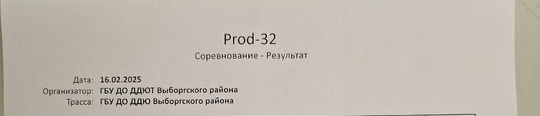

In [78]:
# sort the cells from high to low
cells = sorted(cells, key=lambda a: (a[1], a[0]))
upper_y_cell = cells[0]

x, y, w, h = upper_y_cell
ih, iw, _ = img.shape

y_b = 0
if y / ih > 0.16:
  # make the header 18% at max of the image height
  y_b = int(ih * (y/ih - 0.16))
himg = img[y_b:y].copy()
cv2_imshow(himg)

Great, the we've got the header. Now let's "highlight" the contours

dilated image


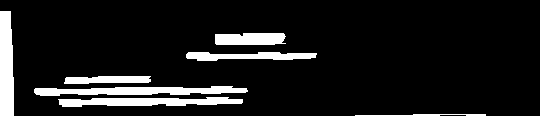

contours


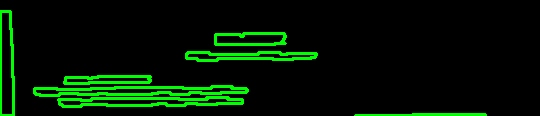

even more contours


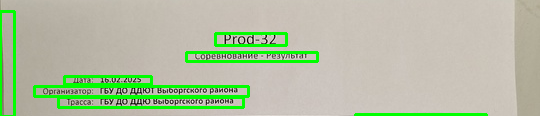

In [79]:
gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

# Create horizontal kernel to merge text in same line
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (20, 1))
dilated = cv2.dilate(thresh, kernel, iterations=1)

h_contours, _ = cv2.findContours(dilated, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

contour_image = np.zeros_like(himg)
cv2.drawContours(contour_image, h_contours, -1, (0, 255, 0), 2)

print("dilated image")
cv2_imshow(dilated)
print("contours")
cv2_imshow(contour_image)

print("even more contours")
t_img = himg.copy()
for cnt in h_contours:
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(t_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
cv2_imshow(t_img)


Good, now filter the rectangles using heuristics:

*   Width greater than height
*   Width to height ratio should be in (4, 35). 35 because the Organizer and Track are quite long
*   Area should be in (0.3, 6)% of header area

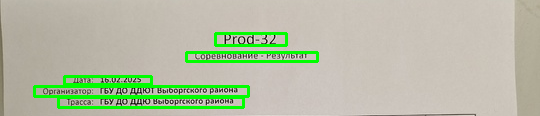

In [80]:
def filter_header_cnt(himg, cnt):
  x, y, w, h = cv2.boundingRect(cnt)
  iw, ih, _ = himg.shape
  gray = cv2.cvtColor(himg, cv2.COLOR_BGR2GRAY)
  return w > h and 4 < w / h < 35 and 0.3 < w * h / (iw * ih) * 100 < 6

# sort the countours from top to bottom
hs_contours = sorted(h_contours, key=lambda c: cv2.boundingRect(c)[1::-1])
hs_contours = [cnt for cnt in hs_contours if filter_header_cnt(himg, cnt)]

t_img = himg.copy()
for cnt in hs_contours:
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(t_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
cv2_imshow(t_img)

Nice, now let's extract text from the highlighted cells, race type and date in particular




In [91]:
from string import ascii_letters, digits

coi = hs_contours[0], hs_contours[2]
for cnt in coi:
  x, y, w, h = cv2.boundingRect(cnt)
  cell_img = himg[y:y+h, x:x+w].copy()
  cv2_imshow(cell_img)

x,y,w,h = cv2.boundingRect(hs_contours[0])
rt_img = himg[y:y+h, x:x+w].copy()
race_type = pytesseract.image_to_string(rt_img, config=f"-c tessedit_char_whitelist={ascii_letters}{digits}-/ -c preserve_interword_spaces=1", lang="eng").strip()
print(f"{race_type = !r}")

x,y,w,h = cv2.boundingRect(hs_contours[2])
rt_img = himg[y:y+h, x:x+w].copy()
date_text = pytesseract.image_to_string(rt_img, config=f"-c tessedit_char_whitelist={digits}. -c preserve_interword_spaces=1", lang="eng").strip()
print(f"{date_text = !r}")

race_type = ''
date_text = ''


Hm, that didn't work. Let's try adding some margin to cropping

In [92]:
margin=3
race_type_margin=6
date_margin = 2 # px

x,y,w,h = cv2.boundingRect(hs_contours[0])
rt_img = himg[y-race_type_margin:y+h+race_type_margin, x-margin:x+w+margin].copy()
cv2_imshow(rt_img)
race_type = pytesseract.image_to_string(rt_img, config=f"-c tessedit_char_whitelist={ascii_letters}{digits}-/ -c preserve_interword_spaces=1", lang="eng").strip()
print(f"{race_type = !r}")

x,y,w,h = cv2.boundingRect(hs_contours[2])
rt_img = himg[y-date_margin:y+h+date_margin, x-margin:x+w+margin].copy()
cv2_imshow(rt_img)
date_text = pytesseract.image_to_string(rt_img, config=f"-c tessedit_char_whitelist={digits}. -c preserve_interword_spaces=1", lang="eng").strip()
print(f"{date_text = !r}")

race_type = 'Prod-32'


date_text = '16.02.2025'


Oooh! Awesome

Let's add fuzzy-matching for race type and regex match for date

Although fuzzy-matchin for race type is less efficient that for fullnames: fullnames are longer

In [94]:
import re
from datetime import datetime

race_types = [
    "Prod-24",
    "Prot-32",
    "ES-32",
    "ES-24",
    "F1-32"
]
print(f"{race_type = !r}, {process.extractOne(race_type, race_types)}")

date_match = re.search(r"\b\d{2}\.\d{2}\.\d{4}\b", date_text)
date = datetime.strptime(date_match.group(0), "%d.%m.%Y").date() if date_match else date_text
print(f"{date_text = !r}, {date = !r}")

race_type = 'Prod-32', ('Prod-24', 86)
date_text = '16.02.2025', date = datetime.date(2025, 2, 16)


Now that we can both segment the image to find race type, race date and race participants and extract text from these segments, we should "combine" all the research to the code, that would be used in the app. This is done in the app, so it won't be shown here.

Some additional research is below. One code cell is about cropping, not just an arbitrary crop with width by half, that was present.
Another one is about removing "dots" noise from the thresholded image. That was also used for "advanced" cropping

More advanced image cropping. Croppes the image at the end of the text

In [ ]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


def crop_image(img, sigma=3, padding=5, threshold_ratio=0.1):
    thresh = img.copy()
    # Vertical projection (sum of pixels per column)
    vertical_proj = np.sum(thresh, axis=0)

    # Smooth the projection to ignore small artifacts
    smoothed = gaussian_filter1d(vertical_proj.astype(float), sigma=sigma)

    # Normalize and threshold
    max_val = np.max(smoothed)
    if max_val == 0:  # No text found
        return img

    threshold = max_val * threshold_ratio
    threshold = np.quantile(vertical_proj, 0.5)
    mask = smoothed > threshold

    # Find start and end of text region
    if np.any(mask):
        x_start = np.argmax(mask)
        x_end = len(mask) - np.argmax(mask[::-1]) - 1
        print(f"{x_start = }, {x_end = }, {img.shape[1] = }")
    else:
        x_start, x_end = 0, img.shape[1]  # Fallback to full width

    return x_start



Make threshold and binary image. Use it to crop the image so that the text is mainly present, not the text and lots of empty cell space. Get the left-most postition of the empty space in cell and return it.

Then, crop the original image using the obtained position. You got the better OCR result, Voila!

Adaptive threshold with larger window and kernel size removes the noise (dots) better: compared 11, 2 and 21, 10. The latter did the job better

image as is ''


cleaned ''
x_start = np.int64(44), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold ''


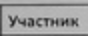

resize ''


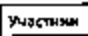

resize cropped ''




image as is '| Перекашкин Даниил'


cleaned '"Перекашини Дуничл'
x_start = np.int64(85), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold '[ Перекашким Даниил'


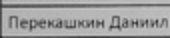

resize 'Перекашкин Даниил'


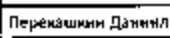

resize cropped ''




image as is '[ Колбинцев Иван.'


cleaned '|потбныцев Ивэн.'
x_start = np.int64(70), x_end = np.int64(305), img.shape[1] = 310


cropped ''


athreshold ''


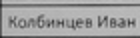

resize 'Колбинцев Иван'


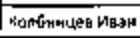

resize cropped ''




image as is '| эсилевский Владимир'


cleaned ''
x_start = np.int64(169), x_end = np.int64(300), img.shape[1] = 310


cropped ''


athreshold ''


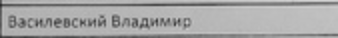

resize 'Василевский Владимир'


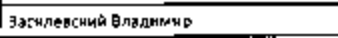

resize cropped ''




image as is '[6злэберннов Егор (Ю).'


cleaned '| болабериноо Егор О'
x_start = np.int64(142), x_end = np.int64(307), img.shape[1] = 312


cropped '`баляберинов Егор'


athreshold '[6злэберннов Егор (Ю)'


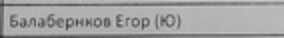

resize ''


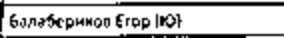

resize cropped ''




image as is '`Косенков Антон.'


cleaned ''
x_start = np.int64(121), x_end = np.int64(307), img.shape[1] = 312


cropped ''


athreshold ''


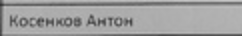

resize ''


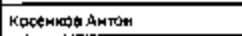

resize cropped 'Косенко'




image as is '[Горелкин Арсений (Ю}'


cleaned 'ГГорелкин Арсений ВОТ'
x_start = np.int64(93), x_end = np.int64(307), img.shape[1] = 312


cropped ''


athreshold 'Торелкин Арсений (Ю)'


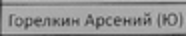

resize 'Горелкин Арсений (Ю)'


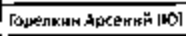

resize cropped ''




image as is '| марнов Александр.'


cleaned ''
x_start = np.int64(80), x_end = np.int64(306), img.shape[1] = 312


cropped ''


athreshold ''


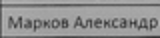

resize 'Марков Александр'


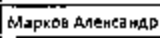

resize cropped ''




image as is '[Комета Алексей,'


cleaned ''
x_start = np.int64(66), x_end = np.int64(309), img.shape[1] = 313


cropped ''


athreshold '[Комета АЛенсей'


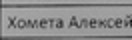

resize 'Хомета Алексей'


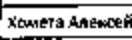

resize cropped 'ро\n\nХолмета Аленсей'




image as is '|бэнов Андрей _'


cleaned 'ибзнов дндреЯ'
x_start = np.int64(69), x_end = np.int64(305), img.shape[1] = 314


cropped ''


athreshold ''


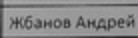

resize 'Жбэнов Андрей'


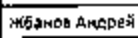

resize cropped ''




image as is '"Петров Кузыиа (Ю)'


cleaned '[Петроя Кузыдь (©)'
x_start = np.int64(79), x_end = np.int64(310), img.shape[1] = 315


cropped ''


athreshold '"Петров Кузьма (Ю)'


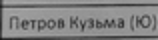

resize 'Петров Кузьма (Ю)'


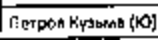

resize cropped ''




image as is '[Емельянов Всеволод (Ю).'


cleaned 'ГЕмальянов Веваслод {К}'
x_start = np.int64(146), x_end = np.int64(307), img.shape[1] = 315


cropped '`Бмельйнов Веваслод {К}'


athreshold 'мель'


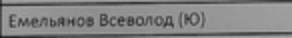

resize 'Емельянов Всеволод (Ю}'


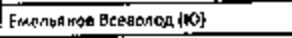

resize cropped '| Еидльйнов Вееаолед {Ю}'




image as is '[петров Роман.'


cleaned 'Глетрою Роман.'
x_start = np.int64(74), x_end = np.int64(310), img.shape[1] = 316


cropped ''


athreshold ''


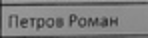

resize 'Петров Роман'


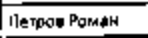

resize cropped ''




image as is 'ГЗимарев Алексей (в/3)'


cleaned ''
x_start = np.int64(97), x_end = np.int64(309), img.shape[1] = 316


cropped ''


athreshold ''


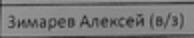

resize ''


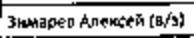

resize cropped 'А.\nЗнмарес Алексей (в/3)'




image as is '`Коряков Валерий.'


cleaned 'ГКоранав Валернй.'
x_start = np.int64(195), x_end = np.int64(310), img.shape[1] = 317


cropped ''


athreshold '`Коряков Валерий.'


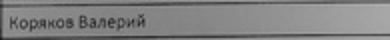

resize 'Коряков Валерий'


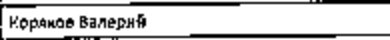

resize cropped '] Коранае Валернй'




image as is '[Ситников Иван (в/з).'


cleaned ''
x_start = np.int64(92), x_end = np.int64(309), img.shape[1] = 318


cropped ''


athreshold ''


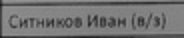

resize 'Ситников Ивам (8/3)'


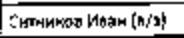

resize cropped 'икоз Ивам (^/3}'




image as is '| рофимов Аленсандр.'


cleaned '[рофимав Аленсандр. |'
x_start = np.int64(195), x_end = np.int64(312), img.shape[1] = 318


cropped ''


athreshold ''


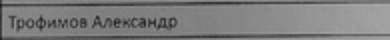

resize 'Трофимов Аленсандр'


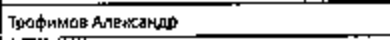

resize cropped 'Трафимав Алеаандр'




image as is '[Демченко Константин (Ю).'


cleaned "'демченно Комстаитин (©."
x_start = np.int64(142), x_end = np.int64(304), img.shape[1] = 318


cropped ''


athreshold '[Демченко Константин (Ю).'


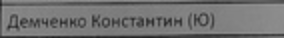

resize 'Демченко Константин (Ю)'


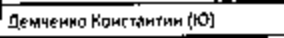

resize cropped ''




image as is 'Тихашин Алексей.'


cleaned ''
x_start = np.int64(100), x_end = np.int64(313), img.shape[1] = 319


cropped ''


athreshold ''


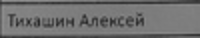

resize '`Тихашин Алексей'


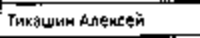

resize cropped '`Тикзшим дленеей'




image as is '`Тихашин Михаил (Ю).'


cleaned 'Тихашин Михэнл ©).'
x_start = np.int64(102), x_end = np.int64(314), img.shape[1] = 320


cropped ''


athreshold '`Тихашин Михаил (Ю).'


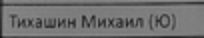

resize 'Тихашин Михаил {Ю)'


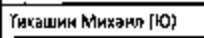

resize cropped ''




image as is '`Морисов Максим (Ю}.'


cleaned '‘орусоз Максим (КИ'
x_start = np.int64(92), x_end = np.int64(314), img.shape[1] = 320


cropped ''


athreshold '`Морисов Максим (Ю}'


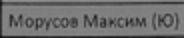

resize 'Морусов Максим (Ю}'


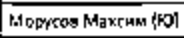

resize cropped ''




In [ ]:
for cell_image in cell_images:
  cimg = cell_image.copy()
  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"image as is {txt.strip()!r}")

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 10
  )
  cv2_imshow(c)

  c = cv2.adaptiveThreshold(
    cimg, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 21,10
  )
  cv2_imshow(c)

  cimg = c.copy()

  kernel = np.ones((3,3), np.uint8)  # Adjust kernel size based on dot size
  cleaned = cv2.fastNlMeansDenoising(cimg)
  # cleaned = cv2.morphologyEx(cimg, cv2.MORPH_OPEN, kernel, iterations=1)
  cv2_imshow(cleaned)
  txt = pytesseract.image_to_string(cleaned, lang="rus")
  print(f"cleaned {txt.strip()!r}")

  x_start = crop_image(cimg.copy())
  crimg = cimg.copy()
  crimg = crimg[:, :x_start]
  cv2_imshow(crimg)
  txt = pytesseract.image_to_string(crimg, lang="rus")
  print(f"cropped {txt.strip()!r}")

  cimg = cell_image.copy()
  cimg=  cimg[:, :x_start]

  # cimg =

  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"athreshold {txt.strip()!r}")

  scale_by = 2
  new_dim = (cimg.shape[1]*scale_by, cimg.shape[0]*scale_by)
  cimg = cv2.resize(cimg, new_dim, interpolation=cv2.INTER_LINEAR)
  cv2_imshow(cimg)
  txt = pytesseract.image_to_string(cimg, lang='rus')
  print(f"resize {txt.strip()!r}")

  scale_by = 2
  new_dim = (crimg.shape[1]*scale_by, crimg.shape[0]*scale_by)
  crimg = cv2.resize(crimg, new_dim, interpolation=cv2.INTER_LINEAR)
  cv2_imshow(crimg)
  txt = pytesseract.image_to_string(crimg, lang='rus')
  print(f"resize cropped {txt.strip()!r}")

  print()
  print()
